# EpiAI 使用教程：全国登革热月发病数预测

> 纯自回归（用历史病例预测未来病例），完整演示数据加载 → 模型训练 → 可视化 → 部署

---

## 1. 环境准备

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from EpiAI.models import sklearn_models, ts_models
from EpiAI.models import torch_models          # 需要 PyTorch，可选

from EpiAI.dataset import (
    ForecastPipeline, CsvLoader, TimeSplit, SlidingWindow,
)
from EpiAI.models.registry import get, list_models
from EpiAI.trainer import EpiAITrainer
from EpiAI.inference import InferencePipeline, ModelVault

---

## 2. 数据加载

登革热: 195 个月 (2010-01-31 ~ 2026-03-01)


/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/IPytho

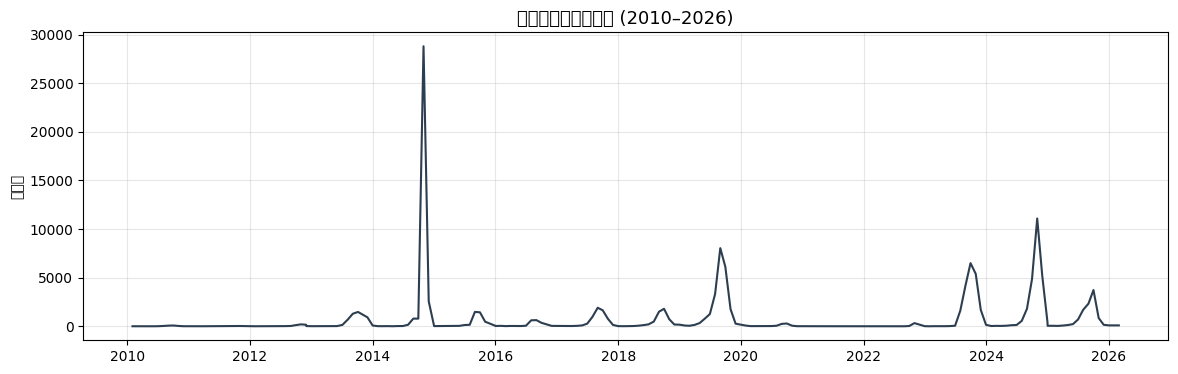

In [2]:
df_raw = pd.read_csv("../data/Infective_disease_china-V3.csv")
df = df_raw[df_raw["Diseases"] == "登革热 Dengue fever"].copy()
df = df.rename(columns={"Year/Month": "time", "Case number": "cases"})
df = df[["time", "cases"]].reset_index(drop=True)
df["time"] = pd.to_datetime(df["time"])
df["cases"] = df["cases"].astype(float)

print(f"登革热: {len(df)} 个月 ({df['time'].min().date()} ~ {df['time'].max().date()})")

plt.figure(figsize=(14, 4))
plt.plot(df["time"], df["cases"], color="#2c3e50")
plt.title("全国登革热月发病数 (2010–2026)", fontsize=13)
plt.ylabel("病例数"); plt.grid(alpha=0.3); plt.show()

---

## 3. 数据管道

In [3]:
df.to_csv("/tmp/dengue.csv", index=False)

bundle = ForecastPipeline(
    loader=CsvLoader(time_col="time", target_cols="cases",
                     feature_cols="cases"),
    split=TimeSplit(train_ratio=0.7, val_ratio=0.15),
    transforms=None,
    window=SlidingWindow(lookback=12, horizon=3),
).run("/tmp/dengue.csv")

print(f"训练: {bundle.train_x.shape}  验证: {bundle.val_x.shape}  测试: {bundle.test_x.shape}")

训练: (122, 12, 1)  验证: (29, 12, 1)  测试: (30, 12, 1)


---

## 4. 训练所有模型

### 4.1 深度学习（需 PyTorch）

In [4]:
results = {}

for name in ["MLP", "LSTM", "CNN"]:
    try:
        model = get(name)(input_dim=bundle.n_features, lookback=12, horizon=3, target_dim=1)
        r = EpiAITrainer(model=model, verbose=False, optimizer_config={"max_epochs": 10}).fit(bundle)
        results[name] = r
        print(f"  ✅ {name}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

  ✅ MLP
  ✅ LSTM
  ✅ CNN


### 4.2 机器学习

In [5]:
for name, kwargs in [
    ("RF", {"n_estimators": 200, "max_depth": 10, "random_state": 42}),
    ("XGB", {"n_estimators": 200, "random_state": 42}),
    ("SVR", {"kernel": "rbf", "C": 1.0}),
]:
    try:
        model = get(name)(input_dim=bundle.n_features, lookback=12, horizon=3, target_dim=1,
                          **{f"{'rf' if name=='RF' else 'xgb' if name=='XGB' else 'svm'}_params": kwargs})
        results[name] = EpiAITrainer(model=model, verbose=False).fit(bundle)
        print(f"  ✅ {name}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

  ✅ RF
  ✅ XGB
  ✅ SVR


### 4.3 时间序列

In [6]:
for name, kwargs in [("ETS", {"seasonal_periods": 12, "seasonal": "add", "trend": "add"}),
                      ("ARIMA", {"seasonal": True, "m": 12})]:
    try:
        model = get(name)(**kwargs)
        results[name] = EpiAITrainer(model=model, verbose=False).fit(bundle)
        print(f"  ✅ {name}")
    except Exception as e:
        print(f"  ❌ {name}: {str(e)[:50]}")

  ✅ ETS
  ✅ ARIMA


---

## 5. ModelVault：入库、对比、部署

In [7]:
vault = ModelVault.from_results(results, bundle)
vault.save("/tmp/dengue_vault/")

print("模型对比总表：")
print(vault.summary().to_string())

模型对比总表：
      paradigm          MAE         RMSE         MAPE        R2  PearsonR   n
model                                                                        
RF     sklearn   778.394775  1465.604858   121.974683  0.679351  0.876249  30
ARIMA       ts  1261.004517  2286.908203   467.682219  0.099193  0.462498  30
XGB    sklearn  1500.619629  2521.539795   129.452169  0.050867  0.491004  30
MLP      torch  1496.858276  2593.297607   247.407866 -0.003923  0.630506  30
CNN      torch  1381.427734  2605.655273   188.289464 -0.013514  0.594091  30
ETS         ts  1772.787109  2681.605225  1355.102825 -0.238579 -0.251610  30
SVR    sklearn  1703.134399  3096.447266    70.328116 -0.431275  0.562117  30
LSTM     torch  1742.323975  3120.267090    97.479820 -0.453380 -0.467215  30


---

## 6. 全部模型预测可视化（时间轴）

/tmp/ipykernel_2448115/4220061940.py:31: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/4220061940.py:31: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/4220061940.py:31: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/4220061940.py:31: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/4220061940.py:31: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/4220061940.py:31: UserWarning: Glyph 30331 (\N{CJK UNIFIED IDEOGRAPH-767B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/4220061940.py:31: UserWarning: Glyph 38761 (\N{CJK UN

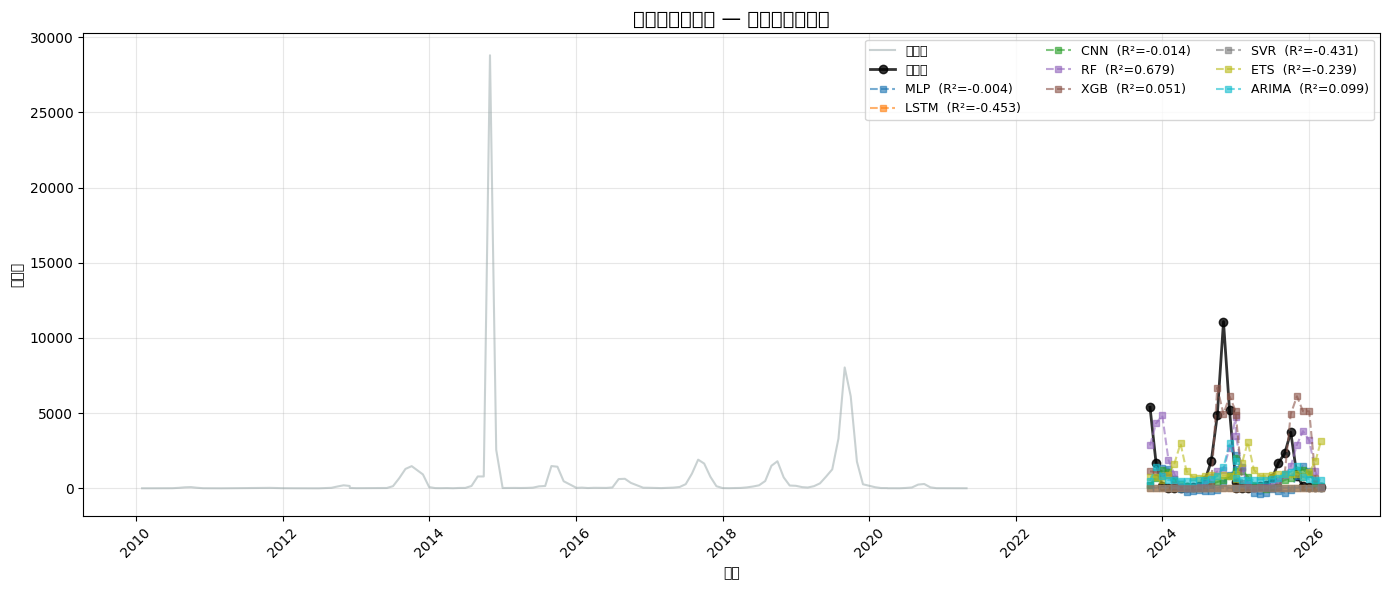

In [8]:
all_time = bundle.train_df["time"].tolist() + bundle.test_df["time"].tolist()
y_all = np.concatenate([bundle.get_y_series("train").ravel(),
                        bundle.get_y_series("test").ravel()])

plt.figure(figsize=(14, 6))

# 训练集曲线
plt.plot(all_time[:len(bundle.train_df)], y_all[:len(bundle.train_df)],
         "-", label="训练集", color="#95a5a6", alpha=0.5)

# 测试集实际值
test_start = len(bundle.train_df)
plt.plot(all_time[test_start:], bundle.get_y_series("test").ravel(),
         "o-", label="实际值", color="black", alpha=0.8, linewidth=2)

# 各模型预测值
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors):
    n = r.predictions.shape[0]
    preds = r.predictions[:, 0, 0]
    m = r.metrics.iloc[0]
    # 预测值对齐到测试集的对应时间点
    pred_time = all_time[test_start:test_start + n]
    plt.plot(pred_time, preds, "s--", label=f"{name}  (R²={m['R2']:.3f})",
             color=color, alpha=0.6, markersize=4)

plt.legend(fontsize=9, ncol=3)
plt.title("登革热月发病数 — 多模型预测对比", fontsize=14)
plt.ylabel("病例数"); plt.xlabel("时间"); plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/tmp/dengue_all_models.png", dpi=150)
plt.show()

In [9]:
preds

array([ 484.0497 , 1440.4569 ,  811.71484,  544.1981 ,  518.59265,
        517.59094,  513.33875,  513.42303,  519.2671 ,  520.0927 ,
        593.56555,  817.13135, 1390.8647 , 2993.205  , 1815.4935 ,
        667.8771 ,  571.66425,  568.4913 ,  561.75323,  566.8507 ,
        576.0898 ,  597.0658 ,  708.23456,  952.0616 , 1108.4484 ,
       1468.8965 ,  772.52454,  601.93134,  584.77924,  581.84534],
      dtype=float32)

In [10]:
pred_time

[Timestamp('2023-10-31 00:00:00'),
 Timestamp('2023-11-30 00:00:00'),
 Timestamp('2023-12-31 00:00:00'),
 Timestamp('2024-01-31 00:00:00'),
 Timestamp('2024-02-29 00:00:00'),
 Timestamp('2024-03-31 00:00:00'),
 Timestamp('2024-04-30 00:00:00'),
 Timestamp('2024-05-31 00:00:00'),
 Timestamp('2024-06-30 00:00:00'),
 Timestamp('2024-07-31 00:00:00'),
 Timestamp('2024-08-31 00:00:00'),
 Timestamp('2024-09-30 00:00:00'),
 Timestamp('2024-10-31 00:00:00'),
 Timestamp('2024-11-30 00:00:00'),
 Timestamp('2024-12-31 00:00:00'),
 Timestamp('2025-01-01 00:00:00'),
 Timestamp('2025-02-01 00:00:00'),
 Timestamp('2025-03-01 00:00:00'),
 Timestamp('2025-04-01 00:00:00'),
 Timestamp('2025-05-01 00:00:00'),
 Timestamp('2025-06-01 00:00:00'),
 Timestamp('2025-07-01 00:00:00'),
 Timestamp('2025-08-01 00:00:00'),
 Timestamp('2025-09-01 00:00:00'),
 Timestamp('2025-10-01 00:00:00'),
 Timestamp('2025-11-01 00:00:00'),
 Timestamp('2025-12-01 00:00:00'),
 Timestamp('2026-01-01 00:00:00'),
 Timestamp('2026-02-

In [ ]:
all_time

---

## 7. 模型部署与实时更新

In [11]:
vault = ModelVault.load("/tmp/dengue_vault/")

# ── 场景 1：所有模型对新数据做预测 ─────────────────────────
# 窗口模型需要特征列，TS 模型自动走 forecast
new_data = bundle.train_df.tail(15).copy()[bundle.feature_names]

all_preds = vault.predict_all(new_data=new_data, steps=6)
print("所有模型推理结果：")
for name, pred in all_preds.items():
    p = vault.get(name).paradigm
    val = pred[0, 0, 0] if p != "ts" else pred[0, 0, 0]
    print(f"  {name:8s} ({p:7s})  → 预测={val:.0f}  形状={pred.shape}")

# ── 场景 2：新观测值到达，更新时序模型 ─────────────────────
# 假设 6 月实际病例数为 1200，7 月为 800
new_cases = np.array([1200, 800], dtype=np.float32)

for name in ["ETS", "ARIMA"]:
    try:
        inferer = vault.get(name)
        updated = inferer.update(new_cases)
        print(f"  {name:8s} update → {updated.ravel().round(0).astype(int)}")
    except KeyError:
        pass  # 模型不在 vault 中（依赖未安装）

# ── 场景 3：从 vault 中挑选任一模型单独推理 ────────────────
best_name = vault.best("R2")
print(f"\n最佳模型单独部署: {best_name}")

inferer = vault.get(best_name)
if inferer.paradigm == "ts":
    fc = inferer.forecast(6)
    print(f"  forecast(6): {fc.ravel().round(0).astype(int)}")
else:
    pred = inferer.predict(new_data)
    print(f"  predict(15行 → 未来3月): {pred[0, :, 0].round(0).astype(int)}")

# 保存 vault（增量更新后）
vault.save("/tmp/dengue_vault/")

/home/xutingfeng/miniforge3/envs/GEO/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1481.)
  result = _VF.lstm(


所有模型推理结果：
  MLP      (torch  )  → 预测=-4  形状=(4, 3, 1)
  LSTM     (torch  )  → 预测=4  形状=(4, 3, 1)
  CNN      (torch  )  → 预测=6  形状=(4, 3, 1)
  RF       (sklearn)  → 预测=9  形状=(4, 3, 1)
  XGB      (sklearn)  → 预测=2  形状=(4, 3, 1)
  SVR      (sklearn)  → 预测=40  形状=(4, 3, 1)
  ETS      (ts     )  → 预测=767  形状=(6, 1, 1)
  ARIMA    (ts     )  → 预测=578  形状=(6, 1, 1)
  ETS      update → [767 757]
  ARIMA    update → [578 847]

最佳模型单独部署: RF
  predict(15行 → 未来3月): [ 9  9 11]


'/tmp/dengue_vault'

---

## 8. 未来预测图

/tmp/ipykernel_2448115/673348554.py:40: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/673348554.py:40: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/673348554.py:40: UserWarning: Glyph 30149 (\N{CJK UNIFIED IDEOGRAPH-75C5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/673348554.py:40: UserWarning: Glyph 20363 (\N{CJK UNIFIED IDEOGRAPH-4F8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/673348554.py:40: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/673348554.py:40: UserWarning: Glyph 30331 (\N{CJK UNIFIED IDEOGRAPH-767B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2448115/673348554.py:40: UserWarning: Glyph 38761 (\N{CJK UNIFIED I

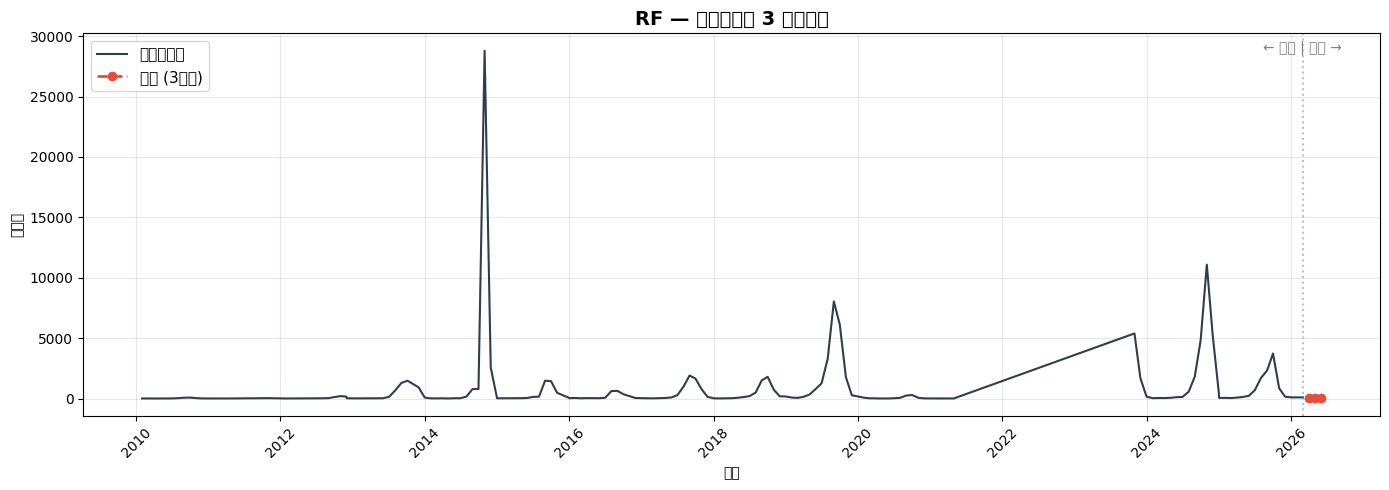

In [12]:
# 用最佳模型预测未来 3 个月
best_name = vault.best("R2")
inferer = vault.get(best_name)

# 时间轴（复用于绘图）
all_time = bundle.train_df["time"].tolist() + bundle.test_df["time"].tolist()
y_all = np.concatenate([bundle.get_y_series("train").ravel(),
                        bundle.get_y_series("test").ravel()])

# 构建未来时间轴
last_time = pd.to_datetime(all_time[-1])
future_dates = pd.date_range(start=last_time + pd.DateOffset(months=1),
                              periods=3, freq="MS")

if inferer.paradigm == "ts":
    fc = inferer.forecast(3)
    future_pred = fc[:, 0, 0]
else:
    pred = inferer.predict(bundle.train_df.tail(15).copy()[bundle.feature_names])
    future_pred = pred[0, :, 0]

plt.figure(figsize=(14, 5))

# 全部历史
plt.plot(all_time, y_all, "-", label="历史实际值", color="#2c3e50", linewidth=1.5)

# 未来预测
plt.plot(future_dates, future_pred, "o--", color="#e74c3c",
         linewidth=2, markersize=6, label=f"预测 (3个月)")

# 分界线 + 标注
plt.axvline(x=last_time, color="gray", linestyle=":", alpha=0.5)
plt.text(last_time, plt.ylim()[1] * 0.95, "← 历史 | 预测 →",
         ha="center", fontsize=10, color="gray")

plt.legend(fontsize=11)
plt.title(f"{best_name} — 登革热未来 3 个月预测", fontsize=14, fontweight="bold")
plt.ylabel("病例数"); plt.xlabel("时间"); plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/tmp/dengue_forecast.png", dpi=150)
plt.show()

---

## 9. 附录

In [ ]:
print("可用模型:", list_models("torch"), list_models("sklearn"), list_models("ts"))